DecisionLens AI

This notebook explores the dataset that will be used to train the NLP component of DecisionLens AI.

The main objectives are:

- Load and inspect the dataset.
- Understand its columns and labels.
- Check missing values and duplicates.
- Analyse the target distribution.
- Examine the length and content of the arguments.
- Identify possible limitations before preprocessing and modelling.

In [ ]:
!pip install -q datasets

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

In [ ]:
pd.set_option('display.max_colwidth', None)

Load Dataset

In [ ]:
dataset = load_dataset(
    "ibm-research/argument_quality_ranking_30k",
    "argument_quality_ranking"
)

README.md:   0%|          | 0.00/5.06k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/3.81M [00:00<?, ?B/s]

dev.csv:   0%|          | 0.00/594k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['argument', 'topic', 'set', 'WA', 'MACE-P', 'stance_WA', 'stance_WA_conf'],
        num_rows: 20974
    })
    validation: Dataset({
        features: ['argument', 'topic', 'set', 'WA', 'MACE-P', 'stance_WA', 'stance_WA_conf'],
        num_rows: 3208
    })
    test: Dataset({
        features: ['argument', 'topic', 'set', 'WA', 'MACE-P', 'stance_WA', 'stance_WA_conf'],
        num_rows: 6315
    })
})

In [ ]:
train_df = dataset['train'].to_pandas()

Exploratory Data Analysis

In [ ]:
train_df.shape

(20974, 7)

In [ ]:
train_df.head()

,argument,topic,set,WA,MACE-P,stance_WA,stance_WA_conf
0,"""marriage"" isn't keeping up with the times. abandon the old thinking and bring something that incorporates all unions - not just those with a man and woman.",We should abandon marriage,train,0.846165,0.297659,1,1.000000
1,.a multi-party system would be too confusing and getting a consensus from the general public would be difficult.,We should adopt a multi-party system,train,0.891271,0.726133,-1,1.000000
2,`people reach their limit when it comes to their quality of life and should be able to end their suffering. this can be done with little or no suffering by assistance and the person is able to say good bye.,Assisted suicide should be a criminal offence,train,0.730395,0.225212,-1,1.000000
3,"100% agree, should they do that, it would be a good thing",We should abolish safe spaces,train,0.236686,0.004104,1,0.805517
4,A ban on naturopathy creates a cohesive front between scientists and the government that can combat the anti-science rhetoric of naturopathic industries.,We should ban naturopathy,train,0.753805,0.337724,1,1.000000


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20974 entries, 0 to 20973
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   argument        20974 non-null  object 
 1   topic           20974 non-null  object 
 2   set             20974 non-null  object 
 3   WA              20974 non-null  float64
 4   MACE-P          20974 non-null  float64
 5   stance_WA       20974 non-null  int64  
 6   stance_WA_conf  20974 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.1+ MB


In [ ]:
train_df.isnull().sum()

,0
argument,0
topic,0
set,0
WA,0
MACE-P,0
stance_WA,0
stance_WA_conf,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df['argument'].duplicated().sum()

np.int64(1)

No missing and duplicated values were found. The dataset is complete and imputation is required before processing.

In [ ]:
categorical = train_df.select_dtypes(include='object').columns
categorical

Index(['argument', 'topic', 'set'], dtype='object')

In [ ]:
numerical = train_df.select_dtypes(exclude='object').columns
numerical

Index(['WA', 'MACE-P', 'stance_WA', 'stance_WA_conf'], dtype='object')

In [ ]:
for col in categorical:
  print('\n')
  print(train_df[col].value_counts())



argument
The true purposes of telemarketing are to pressure feeble-minded people into buying things they\ndon't really want, and to make it easier to get away with fraud                                            2
telemarketers need the job and the money.                                                                                                                                                                   1
telemarketers  try to force a product or service without caring if you even need it                                                                                                                         1
telemarketeeers have business rights just as any legitimate business.                                                                                                                                       1
telemarkerting provides much needed  jobs to people without other skill sets                                                                                         

In [ ]:
for col in numerical:
  print('\n')
  print(train_df[col].value_counts())



WA
1.000000    4110
0.950681      26
0.946203      15
0.804861      14
0.867453      13
            ... 
0.629430       1
0.881837       1
0.841521       1
0.753805       1
0.729705       1
Name: count, Length: 15140, dtype: int64


MACE-P
0.742473    27
0.893684    17
0.474839    16
0.910987    16
0.681632    14
            ..
0.185558     1
0.982356     1
0.717211     1
0.008374     1
0.258152     1
Name: count, Length: 18708, dtype: int64


stance_WA
 1    10648
-1    10326
Name: count, dtype: int64


stance_WA_conf
1.000000    14857
0.928569       12
0.928019        8
0.896395        7
0.887258        6
            ...  
0.899593        1
0.592515        1
0.897611        1
0.805720        1
0.557824        1
Name: count, Length: 5755, dtype: int64


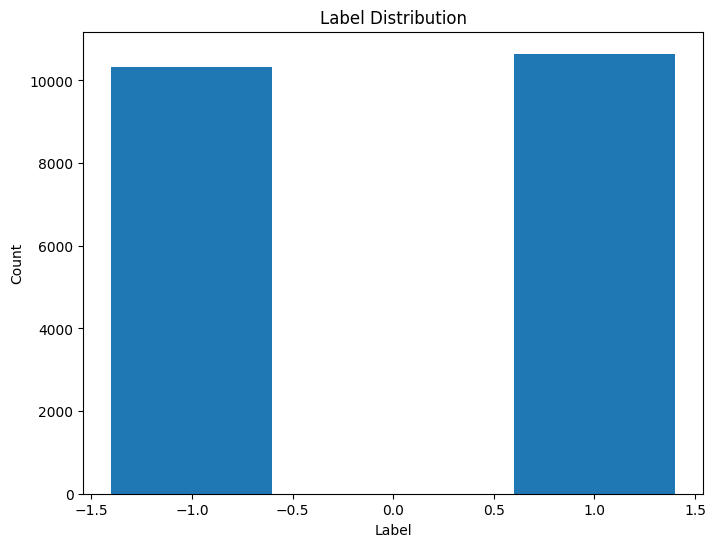

In [ ]:
plt.figure(figsize=(8,6))
plt.bar(train_df['stance_WA'].value_counts().index, train_df['stance_WA'].value_counts().values)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [ ]:
train_df['character_count'] = train_df['argument'].str.len()
train_df['word_count'] = train_df['argument'].str.split().str.len()

In [ ]:
train_df.head()

,argument,topic,set,WA,MACE-P,stance_WA,stance_WA_conf,character_count,word_count
0,"""marriage"" isn't keeping up with the times. abandon the old thinking and bring something that incorporates all unions - not just those with a man and woman.",We should abandon marriage,train,0.846165,0.297659,1,1.000000,157,27
1,.a multi-party system would be too confusing and getting a consensus from the general public would be difficult.,We should adopt a multi-party system,train,0.891271,0.726133,-1,1.000000,112,18
2,`people reach their limit when it comes to their quality of life and should be able to end their suffering. this can be done with little or no suffering by assistance and the person is able to say good bye.,Assisted suicide should be a criminal offence,train,0.730395,0.225212,-1,1.000000,208,40
3,"100% agree, should they do that, it would be a good thing",We should abolish safe spaces,train,0.236686,0.004104,1,0.805517,57,12
4,A ban on naturopathy creates a cohesive front between scientists and the government that can combat the anti-science rhetoric of naturopathic industries.,We should ban naturopathy,train,0.753805,0.337724,1,1.000000,153,22


In [ ]:
train_df['character_count'].describe().round(2)

,character_count
count,20974.00
mean,107.69
std,43.19
min,35.00
25%,74.00
50%,101.00
75%,136.00
max,245.00


In [ ]:
train_df['word_count'].describe().round(2)

,word_count
count,20974.00
mean,18.18
std,7.58
min,4.00
25%,12.00
50%,17.00
75%,23.00
max,44.00


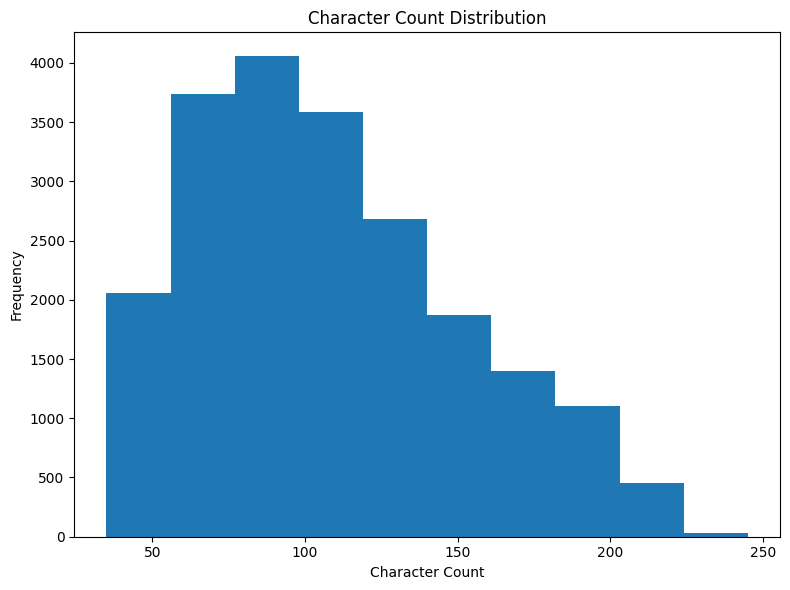

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(train_df['character_count'], bins=10)
plt.title('Character Count Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

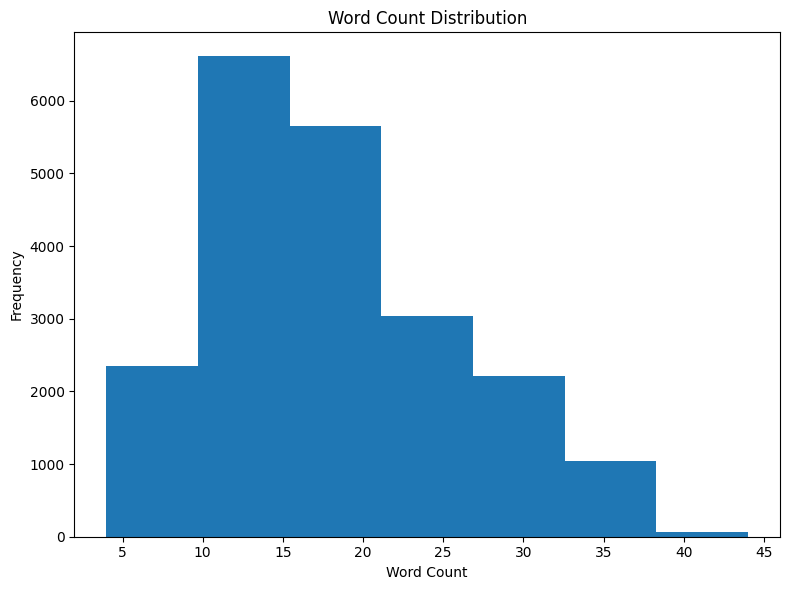

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(train_df['word_count'], bins=7)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show

In [ ]:
train_df.sample(n=10, random_state=42)

,argument,topic,set,WA,MACE-P,stance_WA,stance_WA_conf,character_count,word_count
2516,"Collectivism does not reward individuals for hardwork, which removes the ability for people to improve their lives through their own dedication and volition, and is ultimately unjust.",We should oppose collectivism,train,1.000000,0.983434,1,1.000000,183,27
19687,"we shouldn't ban cosmetic surgery altogether because there are people who need it like burn victims. also, i see no reason why this surgery should be banned. it can raise self esteem and its a personal choice",We should ban cosmetic surgery,train,0.868537,0.965482,-1,1.000000,208,37
12354,"safe spaces provide a needed service, to give people a place to go where they won't be judges for who they are",We should abolish safe spaces,train,0.869529,0.807479,-1,1.000000,110,22
19139,we should not prohibit flag burning because if someone wants to burn a flag let them,We should prohibit flag burning,train,0.431843,0.000221,-1,1.000000,84,16
9298,"marriage is an outdated, patriarchal and historically religious institution which has no place in a contemporary secular society.",We should abandon marriage,train,0.959376,0.939959,1,1.000000,129,18
3492,economic sanctions can help stop a country or prevent a country from negative acts and behaviors,We should end the use of economic sanctions,train,1.000000,0.954739,-1,0.826395,96,16
19475,we should subsidize space exploration because it is beneficial for educational purposes,We should subsidize space exploration,train,0.700954,0.296493,1,1.000000,87,12
15750,"there are some crimes so heinous, such as child rape and murder, that capital punishment is the only appropriate punishment for the crime as well as to act as a deterrent to others",We should abolish capital punishment,train,0.867230,0.711148,-1,1.000000,180,33
17084,"we are able to make this loving and selfless gesture when our animal companions are in too much pain, why can't we show the same compassion to humans?",Assisted suicide should be a criminal offence,train,0.923670,0.888022,-1,1.000000,150,28
7685,it is unfair to say every parent is ill-equipped to provide a well-rounded education..,Homeschooling should be banned,train,1.000000,0.813570,-1,0.898349,86,14


In [ ]:
validation_df = dataset['validation'].to_pandas()

In [ ]:
validation_df.shape

(3208, 7)

In [ ]:
validation_df.head()

,argument,topic,set,WA,MACE-P,stance_WA,stance_WA_conf
0,"\ero-tolerance policy in schools should not be adopted as circumstances are often not black and white, being more nuanced. no one should be written off due to a mistake of judgement.",We should adopt a zero-tolerance policy in schools,dev,0.721192,0.396953,-1,1.0
1,"a bad score in an intelligence test is a blow to our children's drive and self esteem, reducing motivation and causing harm.",Intelligence tests bring more harm than good,dev,1.000000,0.993543,1,1.0
2,"a bad score in an intelligence test is a blow to people sense of worth, hurting not only their feeling's but also this society's development.",Intelligence tests bring more harm than good,dev,0.638716,0.076707,1,1.0
3,A ban would send a strong message that better business practices are needed.,Payday loans should be banned,dev,0.832302,0.444728,1,1.0
4,a blockade is sometimes the only non-violent option available in trying to force a diplomatic hand.,Blockade of the Gaza Strip should be ended,dev,0.871867,0.998656,-1,1.0


In [ ]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3208 entries, 0 to 3207
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   argument        3208 non-null   object 
 1   topic           3208 non-null   object 
 2   set             3208 non-null   object 
 3   WA              3208 non-null   float64
 4   MACE-P          3208 non-null   float64
 5   stance_WA       3208 non-null   int64  
 6   stance_WA_conf  3208 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 175.6+ KB


In [ ]:
validation_df.isnull().sum()

,0
argument,0
topic,0
set,0
WA,0
MACE-P,0
stance_WA,0
stance_WA_conf,0


In [ ]:
validation_df.duplicated().sum()

np.int64(0)

In [ ]:
test_df = dataset['test'].to_pandas()

In [ ]:
test_df.shape

(6315, 7)

In [ ]:
test_df.head()

,argument,topic,set,WA,MACE-P,stance_WA,stance_WA_conf
0,6 million people died so to deny the holocaust should be a crime against their memory,Holocaust denial should be a criminal offence,test,0.738337,0.483102,1,1.0
1,a ban would only bring problems in gender equality,We should prohibit women in combat,test,0.721728,0.696794,-1,1.0
2,"A centralized system of criminal defense would mean that all people would have access to the same standard of legal counsel, meaning that wealth and power can't be used to avoid justice.",The use of public defenders should be mandatory,test,0.828674,0.928340,1,1.0
3,"a constantly growing population requires large volumes of food are needed at a constant pace all year, which can't be provided by less intensive farming, so we absolutely retain at least some factory techniques",We should ban factory farming,test,0.732927,0.576280,-1,1.0
4,a country would fall apart under libertarianism as there is not any good oversight of the people.,We should adopt libertarianism,test,0.790850,0.535651,-1,1.0


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6315 entries, 0 to 6314
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   argument        6315 non-null   object 
 1   topic           6315 non-null   object 
 2   set             6315 non-null   object 
 3   WA              6315 non-null   float64
 4   MACE-P          6315 non-null   float64
 5   stance_WA       6315 non-null   int64  
 6   stance_WA_conf  6315 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 345.5+ KB


In [ ]:
test_df.isnull().sum()

,0
argument,0
topic,0
set,0
WA,0
MACE-P,0
stance_WA,0
stance_WA_conf,0


In [ ]:
test_df.duplicated().sum()

np.int64(0)

In [49]:
test_df['character_count'] = train_df['argument'].str.len()
test_df['word_count'] = train_df['argument'].str.split().str.len()

In [50]:
validation_df['character_count'] = train_df['argument'].str.len()
validation_df['word_count'] = train_df['argument'].str.split().str.len()

In [51]:
print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(20974, 9)
(3208, 9)
(6315, 9)


In [52]:
train_df.to_csv('/content/drive/MyDrive/PROYECT_5/train.csv', index=False)
validation_df.to_csv('/content/drive/MyDrive/PROYECT_5/validation.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/PROYECT_5/test.csv', index=False)

Conclusions

- The training dataset contains 20,974 English arguments.
- No missing values were found.
- No duplicated rows were detected.
- The target variable contains two classes: `1` and `-1`.
- The classes are well balanced.
- Arguments are short, with an average of approximately 18 words.
- No extreme text-length outliers were found.
- The dataset is suitable for training a lightweight binary text classifier.